In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

def get_variant(reference, mutations, start_index=1):

    if isinstance(reference, (str, np.str_)):
        reference = np.array(list(reference))
        return_as_string = True
    
    variant = reference.copy()
    for mut in mutations:
        if mut!='WT':
            pos = int(mut[1:-1])-start_index
            variant[pos] = mut[-1]

    if return_as_string:
        return ''.join(variant)
    else:   
        return variant

# Import Pho4 data

In [2]:
pho4_wt = 'MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQNDELNSQENHNSSENGNENENEQDSLALDDLDRAFELVEGMDMDWMMPSHAHHSPATTATIKPRLLYSPLIHTQSAVPVTISPNLVATATSTTSANKVTKNKSNSSPYLNKRRGKPGPDSATSLFELPDSVIPTPKPKPKPKQYPKVILPSNSTRRVSPVTAKTSSSAEGVVVASESPVIAPHGSSHSRSLSKRRSSGALVDDDKRESHKHAEQARRNRLAVALHELASLIPAEWKQQNVSAAPSKATTVEAACRYIRHLQQNVST'


In [3]:
dna_sequences = ['CCACGTGA', 'ACACGTGA', 'CCACGCGA', 'TCACGTGC', 'CACGTT', 'CATGTG', 'CAACGTG', 'GCACGTGC', 'CGCGTG']

dfs = {}
for dna_seq in dna_sequences:
    csv_filename = f"../raw_data/PHO4_YEAST_Aditham_2021/PHO4_Kd_{dna_seq}_100mM_NaCl.csv"
    df = pd.read_csv(csv_filename, index_col=0)
    
    df = df[['id', 'ddG_wt', 'estimate']]

    # Assuming your dataframe is called `df`
    # Group by 'id' and aggregate mean and SEM
    summary_df = df.groupby('id').agg({
        'ddG_wt': ['mean', sem],
        'estimate': ['mean', sem]
    })
    
    # Flatten the MultiIndex columns
    summary_df.columns = ['ddG_wt_mean', 'ddG_wt_sem', 'Kd_mean', 'Kd_sem']

    summary_df['aa_sequence'] = [get_variant(pho4_wt, [_id]) for _id in summary_df.index] 
    
    dfs[dna_seq.split('_')[0]] = summary_df

/n/groups/marks/software/anaconda_o2/envs/protein_env/lib/python3.7/site-packages/numpy/core/_methods.py:263: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims, where=where)
/n/groups/marks/software/anaconda_o2/envs/protein_env/lib/python3.7/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [28]:
summary_df

,ddG_wt_mean,ddG_wt_sem,Kd_mean,Kd_sem,aa_sequence
id,,,,,
A245V,-0.229780,0.003520,9783.759804,58.158924,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...
A258L,0.216852,0.023756,23180.672535,1714.408640,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...
A258R,-0.105153,0.015358,14330.253158,828.967499,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...
A258V,0.206804,0.068120,25093.507698,3300.758425,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...
A261V,-0.006822,0.071243,17857.403039,2844.196916,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...
A267V,-0.063607,0.070751,14695.331440,758.255204,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...
A269V,0.515101,0.067779,40833.583519,4682.751717,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...
A274V,0.256716,0.033201,24317.834911,1294.125103,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...
A279V,-0.139720,0.032795,13715.354291,1282.069322,MGRTTSEGIHGFVDDLEPKSSILDKVGDFITVNTKRHDGREDFNEQ...


In [29]:
for code,summary_df in dfs.items():

    filename = f"../processed_data/PHO4_YEAST_Aditham_2021/PHO4_YEAST_Aditham_2021_{code}.csv"
    filename2 = f"/n/groups/marks/users/sam/SpecificityStudio/DMS_assays/PHO4_YEAST_Aditham_2021_{code}.csv"
    df = summary_df.reset_index().rename(columns={'id': 'mutant'}).set_index('mutant').rename({'WT':'M1M'})
    #df.to_csv(filename)
    df['mutated_sequence'] = df['aa_sequence']
    df.to_csv(filename2)
    
    #summary_df.reset_index().rename(columns={'id': 'mutant'}).rename({"WT":"M1M"}, axis=0).to_csv(filename)

In [5]:
multiindex_df = pd.concat(dfs, names=["DNA_seq", "id"])

In [6]:
multiindex_df.to_pickle(f"../processed_data/PHO4_YEAST_Aditham_2021/PHO4_YEAST_Aditham_2021_all.pkl")

Text(0, 0.5, 'ddG (CACGTT)')

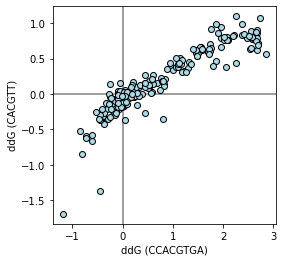

In [7]:
lig1 = "CCACGTGA"
lig2 = "CACGTT"

# Extract ddG_mean for each ligand
ddg1 = multiindex_df.loc[lig1, "ddG_wt_mean"]
ddg2 = multiindex_df.loc[lig2, "ddG_wt_mean"]

ddg_compare = pd.DataFrame({
    lig1: ddg1,
    lig2: ddg2
}).dropna()  # Drop any IDs not present in both

plt.figure(figsize=(4,4))
plt.axvline(0, c='gray', zorder=-10); plt.axhline(0, c='gray', zorder=-10)
plt.scatter(ddg_compare[lig1], ddg_compare[lig2], ec='k', c='lightblue')
plt.xlabel(f"ddG ({lig1})")
plt.ylabel(f"ddG ({lig2})")

Text(0, 0.5, 'ddG (CATGTG)')

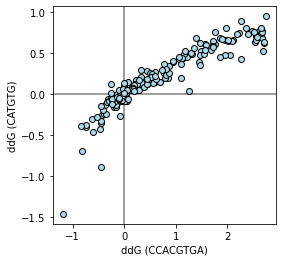

In [14]:
lig1 = "CCACGTGA"
lig2 = "CATGTG"

# Extract ddG_mean for each ligand
ddg1 = multiindex_df.loc[lig1, "ddG_wt_mean"]
ddg2 = multiindex_df.loc[lig2, "ddG_wt_mean"]

ddg_compare = pd.DataFrame({
    lig1: ddg1,
    lig2: ddg2
}).dropna()  # Drop any IDs not present in both

plt.figure(figsize=(4,4))
plt.axvline(0, c='gray', zorder=-10); plt.axhline(0, c='gray', zorder=-10)
plt.scatter(ddg_compare[lig1], ddg_compare[lig2], ec='k', c='lightblue')
plt.xlabel(f"ddG ({lig1})")
plt.ylabel(f"ddG ({lig2})")

In [9]:
multiindex_df.loc[['CCACGTGA', 'CACGTT'], 'ddG_wt_mean'].id

AttributeError: 'Series' object has no attribute 'id'

In [10]:
lig1 = "CCACGTGA"
lig2 = "CATGTG"

In [11]:
from sklearn.linear_model import LinearRegression

def calculate_residuals(lig1, lig2):

    # Extract ddG_mean for each ligand
    ddg1 = multiindex_df.loc[lig1, "ddG_wt_mean"]
    ddg2 = multiindex_df.loc[lig2, "ddG_wt_mean"]
    
    ddg_compare = pd.DataFrame({
        lig1: ddg1,
        lig2: ddg2
    }).dropna()  # Drop any IDs not present in both

    lr = LinearRegression().fit(ddg1, ddg2)

In [12]:
pip install statsmodels

     |████████████████████████████████| 9.9 MB 5.8 MB/s eta 0:00:01
  Using cached patsy-1.0.1-py2.py3-none-any.whl (232 kB)
Note: you may need to restart the kernel to use updated packages.


In [52]:
import pandas as pd
import statsmodels.api as sm

def calculate_residuals(lig1, lig2):

    # Extract ddG_mean for each ligand
    ddg1 = multiindex_df.loc[lig1, "ddG_wt_mean"]
    ddg2 = multiindex_df.loc[lig2, "ddG_wt_mean"]
    
    ddg_compare = pd.DataFrame({
        lig1: ddg1,
        lig2: ddg2
    }).dropna()  # Drop any IDs not present in both

    # Linear regression: ddg2 ~ ddg1
    X = sm.add_constant(ddg_compare[lig1])  # Adds intercept term
    model = sm.OLS(ddg_compare[lig2], X).fit()
    predicted = model.predict(X)
    
    # Residuals
    residuals = ddg2 - predicted
    
    # Combine results into a DataFrame
    results = pd.DataFrame({
        'ddg1': ddg1,
        'ddg2': ddg2,
        'predicted_ddg2': predicted,
        'residual': residuals
    })

    return results

In [51]:
ddg1

id
A245V   -0.069392
A258L    0.955581
A258R    0.589342
A258V    1.453271
A261V    0.564451
           ...   
W281V    0.592838
WT      -0.013719
Y302A    2.261019
Y302H    2.370713
Y302V    1.903103
Name: ddG_wt_mean, Length: 215, dtype: float64

In [58]:
all_residuals = pd.concat([calculate_residuals("CCACGTGA", i)['residual'].rename(f"{i}_residual") for i in dna_sequences if i!="CCACGTGA"], axis=1).dropna()
all_residuals

,ACACGTGA_residual,CCACGCGA_residual,TCACGTGC_residual,CACGTT_residual,CATGTG_residual,CAACGTG_residual,GCACGTGC_residual,CGCGTG_residual
id,,,,,,,,
A258L,0.038405,0.143574,0.291279,0.118645,0.098273,0.011303,0.131629,0.039748
A258R,-0.275686,-0.035577,-0.679993,-0.099169,-0.026231,-0.103235,0.151164,-0.170654
A261V,0.148853,-0.025935,0.294513,-0.102855,-0.028379,-0.040784,-0.258527,-0.064738
A267V,0.066831,-0.308152,0.361188,0.008184,0.059666,-0.026051,-0.151213,-0.034812
A269V,-0.020931,0.095174,0.121407,0.131171,0.086112,0.112774,-0.046232,0.101570
...,...,...,...,...,...,...,...,...
W281V,0.273919,0.082198,0.119706,0.087223,0.048469,0.110366,-0.260204,0.150472
WT,0.048462,0.092241,-0.033196,0.086689,0.041143,0.050019,0.057929,0.103622
Y302A,0.148387,0.265190,0.071275,0.310592,0.164458,0.204211,-0.401945,0.288069


In [93]:
dna_sequences

['CCACGTGA',
 'ACACGTGA',
 'CCACGCGA',
 'TCACGTGC',
 'CACGTT',
 'CATGTG',
 'CAACGTG',
 'GCACGTGC',
 'CGCGTG']

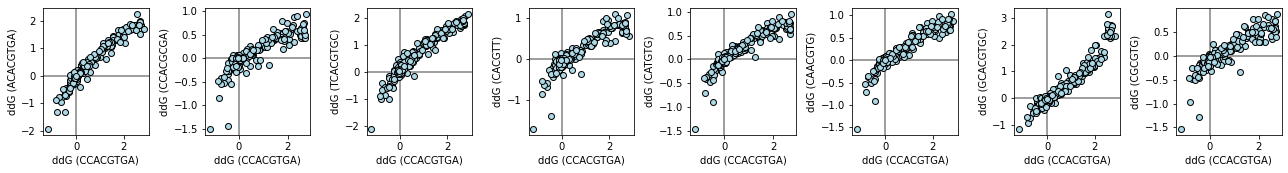

In [99]:
fig, ax = plt.subplots(1, 8, figsize=(18,2.5))

for n,i in enumerate(dna_sequences[1:]):
        
    # Extract ddG_mean for each ligand
    ddg1 = multiindex_df.loc["CCACGTGA", "ddG_wt_mean"]
    ddg2 = multiindex_df.loc[i, "ddG_wt_mean"]
    
    ddg_compare = pd.DataFrame({
        "CCACGTGA": ddg1,
        i: ddg2
    }).dropna()  # Drop any IDs not present in both

    ax[n].axvline(0, c='gray', zorder=-10); ax[n].axhline(0, c='gray', zorder=-10)
    ax[n].scatter(ddg_compare["CCACGTGA"], ddg_compare[i], ec='k', c='lightblue')
    ax[n].set_xlabel(f"ddG (CCACGTGA)")
    ax[n].set_ylabel(f"ddG ({i})")

plt.tight_layout()

Text(0, 0.5, 'ddG (CATGTG)')

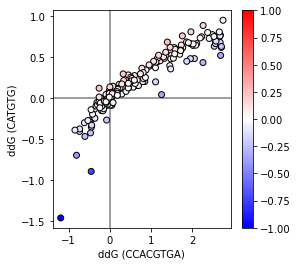

In [55]:
res = calculate_residuals("CCACGTGA", 'CATGTG')

lig1 = "CCACGTGA"
lig2 = "CATGTG"

# Extract ddG_mean for each ligand
ddg1 = multiindex_df.loc[lig1, "ddG_wt_mean"]
ddg2 = multiindex_df.loc[lig2, "ddG_wt_mean"]

ddg_compare = pd.DataFrame({
    lig1: ddg1,
    lig2: ddg2
}).dropna()  # Drop any IDs not present in both

plt.figure(figsize=(4,4))
plt.axvline(0, c='gray', zorder=-10); plt.axhline(0, c='gray', zorder=-10)
plt.scatter(ddg_compare[lig1], ddg_compare[lig2], ec='k', c=res.loc[ddg_compare.index]['residual'], cmap='bwr', vmax=1, vmin=-1)
plt.colorbar()
plt.xlabel(f"ddG ({lig1})")
plt.ylabel(f"ddG ({lig2})")

In [53]:
calculate_residuals("CCACGTGA", 'CATGTG').sort_values('residual')

,ddg1,ddg2,predicted_ddg2,residual
id,,,,
A289R,-1.193094,-1.461624,-0.416612,-1.045012
H255R,-0.453220,-0.893381,-0.172115,-0.721266
A289K,-0.809667,-0.696043,-0.289906,-0.406138
R262Y,1.253172,0.045063,0.391774,-0.346712
K292E,2.685282,0.523228,0.865026,-0.341798
...,...,...,...,...
R235A,-0.242850,NaN,NaN,NaN
R263A,2.525785,NaN,NaN,NaN
S242V,-0.012810,NaN,NaN,NaN


In [49]:
['residual'].rename(f"{lig2}_residual")

AttributeError: 'list' object has no attribute 'rename'

(array([ 9., 26., 34., 29., 24., 15., 12., 11.,  4.,  3.,  5.,  3.,  2.,
         1.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  1.]),
 array([0.03001911, 0.0485396 , 0.0670601 , 0.0855806 , 0.10410109,
        0.12262159, 0.14114209, 0.15966259, 0.17818308, 0.19670358,
        0.21522408, 0.23374457, 0.25226507, 0.27078557, 0.28930606,
        0.30782656, 0.32634706, 0.34486756, 0.36338805, 0.38190855,
        0.40042905, 0.41894954, 0.43747004, 0.45599054, 0.47451103,
        0.49303153, 0.51155203, 0.53007252, 0.54859302, 0.56711352,
        0.58563402, 0.60415451, 0.62267501, 0.64119551, 0.659716  ,
        0.6782365 , 0.696757  , 0.71527749, 0.73379799, 0.75231849,
        0.77083899, 0.78935948, 0.80787998, 0.82640048, 0.84492097,
        0.86344147, 0.88196197, 0.90048246, 0.91900296, 0.93752346,
        0.95604396]),
 <BarContainer

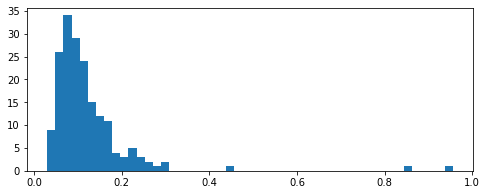

In [62]:
plt.figure(figsize=(8,3))
plt.hist(all_residuals.abs().mean(axis=1), bins=50)

(array([124.,  40.,   9.,   5.,   1.,   1.,   0.,   3.]),
 array([0., 1., 2., 3., 4., 5., 6., 7., 8.]),
 <BarContainer object of 8 artists>)

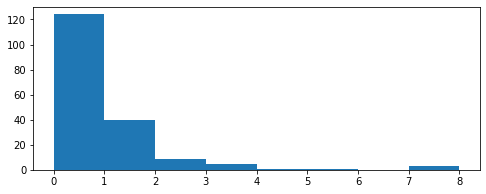

In [132]:
plt.figure(figsize=(8,3))
plt.hist(np.sum(all_residuals.abs()>0.3, axis=1), bins=8)

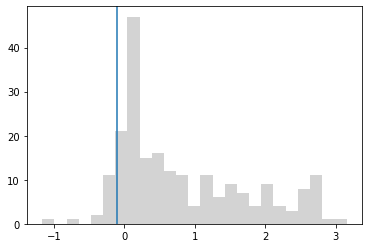

In [117]:
plt.hist(multiindex_df['ddG_wt_mean'].unstack(level=0).max(axis=1), bins=25, color='lightgray')
plt.axvline(-0.1)

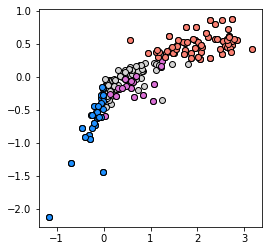

In [145]:
plt.figure(figsize=(4,4))
plt.scatter(multiindex_df['ddG_wt_mean'].unstack(level=0).max(axis=1),
            multiindex_df['ddG_wt_mean'].unstack(level=0).min(axis=1), c='lightgray', ec='k')

sswitchin = np.sum(all_residuals.abs()>0.3, axis=1)>0
sswitchin = sswitchin.loc[sswitchin].index

plt.scatter(multiindex_df['ddG_wt_mean'].unstack(level=0).max(axis=1).loc[sswitchin],
            multiindex_df['ddG_wt_mean'].unstack(level=0).min(axis=1).loc[sswitchin], c='orchid', ec='k')

higher_affinity = multiindex_df['ddG_wt_mean'].unstack(level=0).max(axis=1)<-0
low_affinity = multiindex_df['ddG_wt_mean'].unstack(level=0).min(axis=1)>0.25

plt.scatter(multiindex_df['ddG_wt_mean'].unstack(level=0).max(axis=1).loc[higher_affinity],
            multiindex_df['ddG_wt_mean'].unstack(level=0).min(axis=1).loc[higher_affinity], c='dodgerblue', ec='k')

plt.scatter(multiindex_df['ddG_wt_mean'].unstack(level=0).max(axis=1).loc[low_affinity],
            multiindex_df['ddG_wt_mean'].unstack(level=0).min(axis=1).loc[low_affinity], c='salmon', ec='k')



In [1]:
from evcouplings.couplingns import CouplingsModel

#def load_evc_model(model_name):

    

ModuleNotFoundError: No module named 'evcouplings.couplingns'

In [137]:
all_residuals

,ACACGTGA_residual,CCACGCGA_residual,TCACGTGC_residual,CACGTT_residual,CATGTG_residual,CAACGTG_residual,GCACGTGC_residual,CGCGTG_residual
id,,,,,,,,
A258L,0.038405,0.143574,0.291279,0.118645,0.098273,0.011303,0.131629,0.039748
A258R,-0.275686,-0.035577,-0.679993,-0.099169,-0.026231,-0.103235,0.151164,-0.170654
A261V,0.148853,-0.025935,0.294513,-0.102855,-0.028379,-0.040784,-0.258527,-0.064738
A267V,0.066831,-0.308152,0.361188,0.008184,0.059666,-0.026051,-0.151213,-0.034812
A269V,-0.020931,0.095174,0.121407,0.131171,0.086112,0.112774,-0.046232,0.101570
...,...,...,...,...,...,...,...,...
W281V,0.273919,0.082198,0.119706,0.087223,0.048469,0.110366,-0.260204,0.150472
WT,0.048462,0.092241,-0.033196,0.086689,0.041143,0.050019,0.057929,0.103622
Y302A,0.148387,0.265190,0.071275,0.310592,0.164458,0.204211,-0.401945,0.288069


In [136]:
sswitchin

id
A258L    False
A258R     True
A261V    False
A267V     True
A269V    False
         ...  
W281V    False
WT       False
Y302A     True
Y302H    False
Y302V    False
Length: 183, dtype: bool

In [135]:
multiindex_df['ddG_wt_mean'].unstack(level=0).dropna().sort_values("CCACGTGA", ascending=False)

DNA_seq,CCACGTGA,ACACGTGA,CCACGCGA,TCACGTGC,CACGTT,CATGTG,CAACGTG,GCACGTGC,CGCGTG
id,,,,,,,,,
A299D,2.743957,1.851847,0.940821,2.088108,1.078516,0.953475,1.030377,2.686799,0.877287
R263K,2.703058,1.916615,0.438013,1.767175,0.719680,0.621643,0.764206,2.677748,0.527880
K292E,2.685282,1.520549,0.430788,1.789114,0.624616,0.523228,0.671363,2.334086,0.511736
E259K,2.680655,1.973829,0.741359,1.757230,0.857213,0.771946,0.830481,2.298244,0.620671
R263L,2.674070,1.932252,0.544209,1.848062,0.788757,0.683544,0.768622,2.744966,0.591354
...,...,...,...,...,...,...,...,...,...
N264A,-0.733492,-0.762523,-0.555000,-0.683321,-0.626624,-0.374255,-0.350879,-0.740032,-0.254292
D250A,-0.737070,-0.878296,-0.414351,-0.395689,-0.600514,-0.404724,-0.384276,-0.301963,-0.480094
A289K,-0.809667,-1.300239,-0.833438,-0.993052,-0.844391,-0.696043,-0.708480,-0.933903,-0.969478
